In [1]:
#CWRU Bearing Fault Classification

import os
import numpy as np


#Data files and notebook in the same folder
main_folder = "."

#

filtered_files_1 = []
filtered_files_2 = []
filtered_files_3 = []
filtered_files_4 = []

def load_DE_files(folder, files_list, filtered_files):
    for f in files_list:
        if f.endswith(".npz"):
            file_path = os.path.join(folder, f) 
            #Opens and closes the .npz file safely
            with np.load(file_path) as data:
                #Check for the key "DE" inside the file
                if "DE" in data.files:
                    filtered_files.append(f)
            


folder_1 = '1797 RPM'
#For storing the files in a list
selected_files_1 = ['1797_B_7_DE48.npz', '1797_IR_7_DE48.npz', '1797_Normal.npz', '1797_OR@3_7_DE48.npz']
#
folder_2 = '1772 RPM'
selected_files_2 = ['1772_B_7_DE48.npz', '1772_IR_7_DE48.npz', '1772_Normal.npz', '1772_OR@3_7_DE48.npz']
#
folder_3 = '1750 RPM'
selected_files_3 = ['1750_B_7_DE48.npz', '1750_IR_7_DE48.npz', '1750_Normal.npz', '1750_OR@3_7_DE48.npz']
#
folder_4 = '1730 RPM'
selected_files_4 = ['1730_B_7_DE48.npz', '1730_IR_7_DE48.npz', '1730_Normal.npz', '1730_OR@3_7_DE48.npz']
#

load_DE_files(folder_1, selected_files_1, filtered_files_1)
load_DE_files(folder_2, selected_files_2, filtered_files_2)
load_DE_files(folder_3, selected_files_3, filtered_files_3)
load_DE_files(folder_4, selected_files_4, filtered_files_4)
#
print(filtered_files_1)
print(filtered_files_2)
print(filtered_files_3)
print(filtered_files_4)

['1797_B_7_DE48.npz', '1797_IR_7_DE48.npz', '1797_Normal.npz', '1797_OR@3_7_DE48.npz']
['1772_B_7_DE48.npz', '1772_IR_7_DE48.npz', '1772_Normal.npz', '1772_OR@3_7_DE48.npz']
['1750_B_7_DE48.npz', '1750_IR_7_DE48.npz', '1750_Normal.npz', '1750_OR@3_7_DE48.npz']
['1730_B_7_DE48.npz', '1730_IR_7_DE48.npz', '1730_Normal.npz', '1730_OR@3_7_DE48.npz']


In [2]:
#Data exploration

def data_exp(folder, filtered_files):
    Target_keys = ["DE", "FE", "BA"]
    print(f"\n{'='*60}\nExploring Folder: {folder}\n{'='*60}")
    
    for fi in filtered_files:
        if not fi.endswith(".npz"):
            continue
        
        file_path = os.path.join(folder, fi)
        
        with np.load(file_path) as data:
            
            print(f"\nfile name: {fi}")
            print("Keys:")
            print(data.files)
            print("-"*80)
            
            for key in Target_keys:
                if key not in data:
                    print(f" {key}: Missing")
                    continue
    
                arr = data[key]  #Array
                head_5 = arr[:5] #fIRST five samples
    
                head_5_sq = np.squeeze(head_5) #For readability
    
                print(f" {key}: shape={arr.shape}, dtype={arr.dtype}")
                print(f"   First 5 data points: {head_5_sq}")



data_groups = [
    (folder_1, filtered_files_1),
    (folder_2, filtered_files_2),
    (folder_3, filtered_files_3),
    (folder_4, filtered_files_4)
]

#
for folder, files_list in data_groups:
    data_exp(folder, files_list)


Exploring Folder: 1797 RPM

file name: 1797_B_7_DE48.npz
Keys:
['DE', 'FE']
--------------------------------------------------------------------------------
 DE: shape=(244739, 1), dtype=float64
   First 5 data points: [-0.111192   -0.08302892 -0.04234892  0.00897046  0.05757785]
 FE: shape=(244739, 1), dtype=float64
   First 5 data points: [-0.09512545 -0.07211455 -0.02609273  0.04232364  0.12286182]
 BA: Missing

file name: 1797_IR_7_DE48.npz
Keys:
['DE', 'FE']
--------------------------------------------------------------------------------
 DE: shape=(243938, 1), dtype=float64
   First 5 data points: [ 0.010016   -0.023788   -0.00792933  0.078876    0.202824  ]
 FE: shape=(243938, 1), dtype=float64
   First 5 data points: [-0.35757879 -0.24455101 -0.1870096  -0.19070869 -0.19070869]
 BA: Missing

file name: 1797_Normal.npz
Keys:
['DE', 'FE']
--------------------------------------------------------------------------------
 DE: shape=(243938, 1), dtype=float64
   First 5 data points:

In [3]:
import os
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

file_map = {
    1797: [
        {"file": "1797_Normal.npz", "label": "Normal"},
        {"file": "1797_IR_7_DE48.npz", "label": "Inner_Race"},
        {"file": "1797_OR@3_7_DE48.npz", "label": "Outer_Race"},
        {"file": "1797_B_7_DE48.npz", "label": "Ball_Fault"}
    ],
    1772: [
        {"file": "1772_Normal.npz", "label": "Normal"},
        {"file": "1772_IR_7_DE48.npz", "label": "Inner_Race"},
        {"file": "1772_OR@3_7_DE48.npz", "label": "Outer_Race"},
        {"file": "1772_B_7_DE48.npz", "label": "Ball_Fault"}
    ],
    1750: [
        {"file": "1750_Normal.npz", "label": "Normal"},
        {"file": "1750_IR_7_DE48.npz", "label": "Inner_Race"},
        {"file": "1750_OR@3_7_DE48.npz", "label": "Outer_Race"},
        {"file": "1750_B_7_DE48.npz", "label": "Ball_Fault"}
    ],
    1730: [
        {"file": "1730_Normal.npz", "label": "Normal"},
        {"file": "1730_IR_7_DE48.npz", "label": "Inner_Race"},
        {"file": "1730_OR@3_7_DE48.npz", "label": "Outer_Race"},
        {"file": "1730_B_7_DE48.npz", "label": "Ball_Fault"}
    ],
    "1730_21": [
        {"file": "1730_Normal.npz", "label": "Normal"},
        {"file": "1730_IR_21_DE48.npz", "label": "Inner_Race"},
        {"file": "1730_OR@3_21_DE48.npz", "label": "Outer_Race"},
        {"file": "1730_B_21_DE48.npz", "label": "Ball_Fault"}
    ]
    
}

#
#
folder_map = {
    1797: "1797 RPM",
    1772: "1772 RPM",
    1750: "1750 RPM",
    1730: "1730 RPM",
    "1730_21": "1730 RPM"
}

#
#
train_rpm = [1797, 1772]
val_rpm = [1750]
test_rpm = [1730]
test2_rpm = ["1730_21"]

#

#


window_size = 1024
#

#Transformation
#Segmentation (windowing)
def load_and_window(file_path, label, window_size=1024):
    #Loading the data
    data = np.load(file_path)

    #Drive End (DE) sensor data is selected
    #Transform the data from (N, 1) to a flat 1D array (N,)
    vibration_signal = data['DE'].ravel()

    #Calculate windows and truncate the leftover data for adjusting the array length 
    #to be divisible by 1024
    num_windows = len(vibration_signal) // window_size
    truncated_signal = vibration_signal[0 : num_windows * window_size]

    segmented_data = truncated_signal.reshape(-1, window_size)

    print(f"Processed {file_path}: created {segmented_data.shape[0]} window of size {window_size}")
    
    return segmented_data, label



#

column_names = ['mean', 'std_deviation', 'variance', 'RMS', 'Peak_value', 'Skewness', 'Kurtosis']

#Feature extraction

def  features_func(row):
    mean_value = np.mean(row)
    std_value = np.std(row)
    var_value = np.var(row)

    #RMS: ______________
    rms_value = np.sqrt(np.mean(row**2))

    #Peak_value: ____________
    peak_value = np.max(np.abs(row))

    #skewness and kurtosis
    skew_value = skew(row)
    kurt_value = kurtosis(row)
    return [mean_value, std_value, var_value, rms_value, peak_value, skew_value, kurt_value]



#
def split_files(rpm_list, split_name):
    x_rows = []
    y_rows = []

    for rpm in rpm_list:
        folder_path = os.path.join(main_folder, folder_map[rpm])
        print(f" RPM {rpm}  ({split_name})")

        for entry in file_map[rpm]:
            file_path = os.path.join(folder_path, entry["file"])

            if not os.path.isfile(file_path):
                print(f" Warning file {file_path} is missing")
                continue

            segments, label = load_and_window(file_path,  entry['label'], window_size=1024)
            for window in segments:
                x_rows.append(features_func(window))
                y_rows.append(label)
    
    x_df = pd.DataFrame(x_rows, columns=column_names)
    y_sr = pd.Series(y_rows, name="Fault_Type")
    return x_df, y_sr




In [4]:
#
x_train, y_train = split_files(train_rpm, "Train")
x_val, y_val = split_files(val_rpm, "Validate")
x_test, y_test = split_files(test_rpm, "Test")
#
x_test2, y_test2 = split_files(test2_rpm, "Test(2)")
#
print("\n" + "="*80)
print("Review the data:")
print(f"Train: {len(x_train):5d} windows")
print(f"RPMs: {train_rpm}")
print("*"*80)

print(f"Validate: {len(x_val):5d} windows")
print(f"RPMs: {val_rpm}")

print("*"*80)
#Test RPMs are unseen during training
print(f"Test: {len(x_test):5d} windows")
print(f"RPMs: {test_rpm}")
print("\n" + "="*80)
#

print("*"*80)
#Test(2) RPMs are unseen during training
print(f"Test(2): {len(x_test2):5d} windows")
print(f"RPMs: {1730}")
print("\n" + "="*80)

#
#Class imbalance check
print("Train class counts:")
print(y_train.value_counts().to_string())
print("-"*80)
print("val class counts:")
print(y_val.value_counts().to_string())
print("-"*80)
print("Test class counts:")
print(y_test.value_counts().to_string())
#
print("-"*80)
print("Test(2) class counts:")
print(y_test2.value_counts().to_string())


 RPM 1797  (Train)
Processed .\1797 RPM\1797_Normal.npz: created 238 window of size 1024
Processed .\1797 RPM\1797_IR_7_DE48.npz: created 238 window of size 1024
Processed .\1797 RPM\1797_OR@3_7_DE48.npz: created 121 window of size 1024
Processed .\1797 RPM\1797_B_7_DE48.npz: created 239 window of size 1024
 RPM 1772  (Train)
Processed .\1772 RPM\1772_Normal.npz: created 472 window of size 1024
Processed .\1772 RPM\1772_IR_7_DE48.npz: created 474 window of size 1024
Processed .\1772 RPM\1772_OR@3_7_DE48.npz: created 473 window of size 1024
Processed .\1772 RPM\1772_B_7_DE48.npz: created 475 window of size 1024
 RPM 1750  (Validate)
Processed .\1750 RPM\1750_Normal.npz: created 473 window of size 1024
Processed .\1750 RPM\1750_IR_7_DE48.npz: created 474 window of size 1024
Processed .\1750 RPM\1750_OR@3_7_DE48.npz: created 474 window of size 1024
Processed .\1750 RPM\1750_B_7_DE48.npz: created 475 window of size 1024
 RPM 1730  (Test)
Processed .\1730 RPM\1730_Normal.npz: created 474 wi

In [5]:
from sklearn.preprocessing import StandardScaler
#
scaler = StandardScaler()
x_train_scaler = pd.DataFrame(scaler.fit_transform(x_train), columns=column_names)
#
x_val_scaler = pd.DataFrame(scaler.transform(x_val), columns=column_names)
#
x_test_scaler = pd.DataFrame(scaler.transform(x_test), columns=column_names)
#
x_test2_scaler = pd.DataFrame(scaler.transform(x_test2), columns=column_names)

print("Feature Scaling (StandardScaler is fit on train only to avoid lekage)")


Feature Scaling (StandardScaler is fit on train only to avoid lekage)


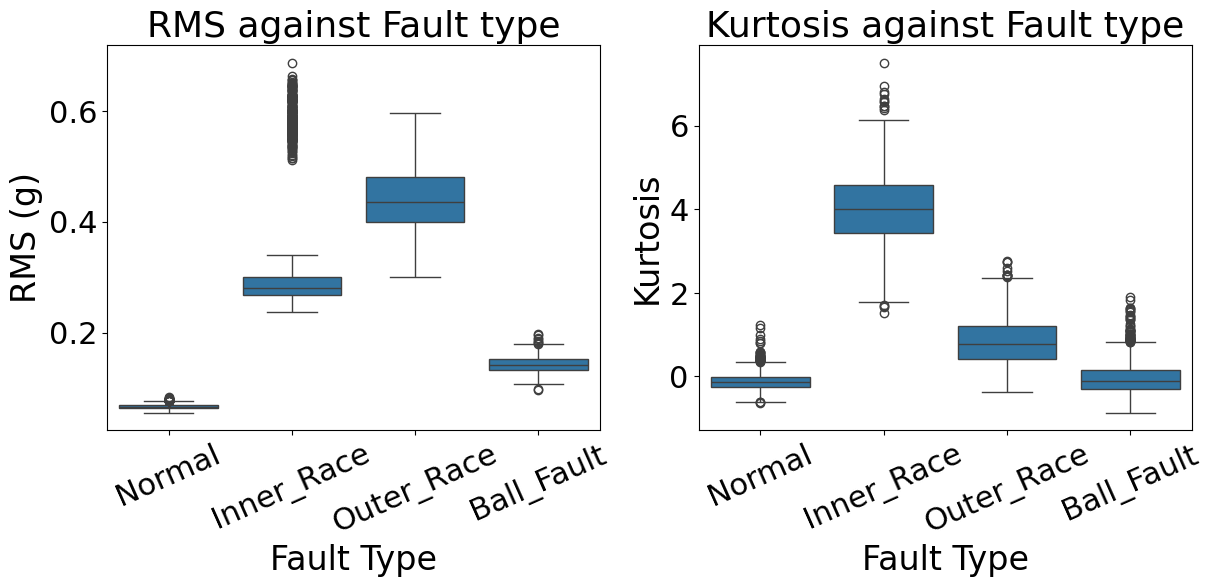

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#RMS box plot
all_x = pd.concat([x_train, x_val, x_test], ignore_index=True)
all_y = pd.concat([y_train, y_val, y_test], ignore_index=True)
df_all = all_x.copy()
df_all["Fault_Type"] = all_y.values

sns.boxplot(data=df_all, x="Fault_Type", y="RMS", ax=axes[0])
axes[0].set_title("RMS against Fault type", fontsize=26)
axes[0].set_xlabel("Fault Type", fontsize=24)
axes[0].set_ylabel("RMS (g)", fontsize=24)
axes[0].tick_params(axis="x", rotation=24, labelsize=22)
axes[0].tick_params(axis="y", labelsize=22)


#
sns.boxplot(data=df_all, x="Fault_Type", y="Kurtosis", ax=axes[1])
axes[1].set_title("Kurtosis against Fault type", fontsize=26)
axes[1].set_xlabel("Fault Type", fontsize=24)
axes[1].set_ylabel("Kurtosis", fontsize=24)
axes[1].tick_params(axis="x", rotation=24, labelsize=22)
axes[1].tick_params(axis="y", labelsize=22)


#
plt.tight_layout

plt.show()

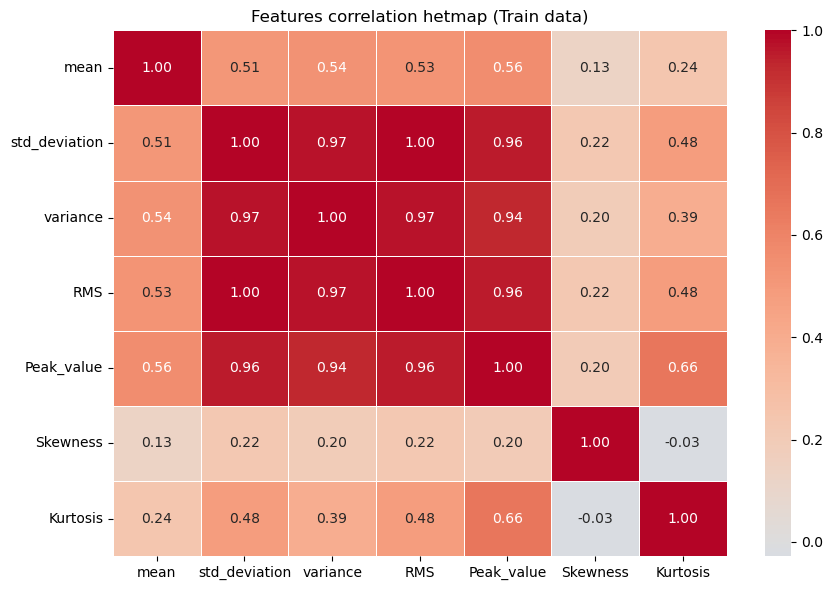

In [7]:
#correlation heat map
plt.figure(figsize=(9, 6))
sns.heatmap(x_train.corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidth=0.5)
plt.title("Features correlation hetmap (Train data)")
plt.tight_layout()
plt.show()

In [8]:
#Baseline model: decision tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train_scaler, y_train)

val_predict_dt = dt.predict(x_val_scaler)

print("Baseline - Decision Tree (validation)")
print("*"*80)
print(f" Accuracy: {accuracy_score(y_val, val_predict_dt)}")
print(f" Macro-F1: {f1_score(y_val, val_predict_dt, average='macro')}")
print()
print(classification_report(y_val, val_predict_dt))




Baseline - Decision Tree (validation)
********************************************************************************
 Accuracy: 0.9783755274261603
 Macro-F1: 0.9783492922912385

              precision    recall  f1-score   support

  Ball_Fault       1.00      1.00      1.00       475
  Inner_Race       0.99      0.92      0.96       474
      Normal       1.00      1.00      1.00       473
  Outer_Race       0.93      0.99      0.96       474

    accuracy                           0.98      1896
   macro avg       0.98      0.98      0.98      1896
weighted avg       0.98      0.98      0.98      1896



In [9]:
#
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced")
rf.fit(x_train_scaler, y_train)
#
val_predict_rf = rf.predict(x_val_scaler)


print("Main Model - Random Forest (validate)")
print("=" * 80)
print(f" Accuracy: {accuracy_score(y_val, val_predict_rf)}")
print(f" Macro-F1: {f1_score(y_val, val_predict_rf, average='macro')}")
print()
print(classification_report(y_val, val_predict_rf))

Main Model - Random Forest (validate)
 Accuracy: 1.0
 Macro-F1: 1.0

              precision    recall  f1-score   support

  Ball_Fault       1.00      1.00      1.00       475
  Inner_Race       1.00      1.00      1.00       474
      Normal       1.00      1.00      1.00       473
  Outer_Race       1.00      1.00      1.00       474

    accuracy                           1.00      1896
   macro avg       1.00      1.00      1.00      1896
weighted avg       1.00      1.00      1.00      1896



In [10]:
test_predict_rf = rf.predict(x_test_scaler)

print("Main Model - Random Forest - Unseen RPM 1730")
print("="*80)
print(f" Accuracy: {accuracy_score(y_test, test_predict_rf)}")
print(f" Macro-F1: {f1_score(y_test, test_predict_rf, average='macro')}")
print()
print(classification_report(y_test, test_predict_rf))

Main Model - Random Forest - Unseen RPM 1730
 Accuracy: 1.0
 Macro-F1: 1.0

              precision    recall  f1-score   support

  Ball_Fault       1.00      1.00      1.00       477
  Inner_Race       1.00      1.00      1.00       474
      Normal       1.00      1.00      1.00       474
  Outer_Race       1.00      1.00      1.00       474

    accuracy                           1.00      1899
   macro avg       1.00      1.00      1.00      1899
weighted avg       1.00      1.00      1.00      1899



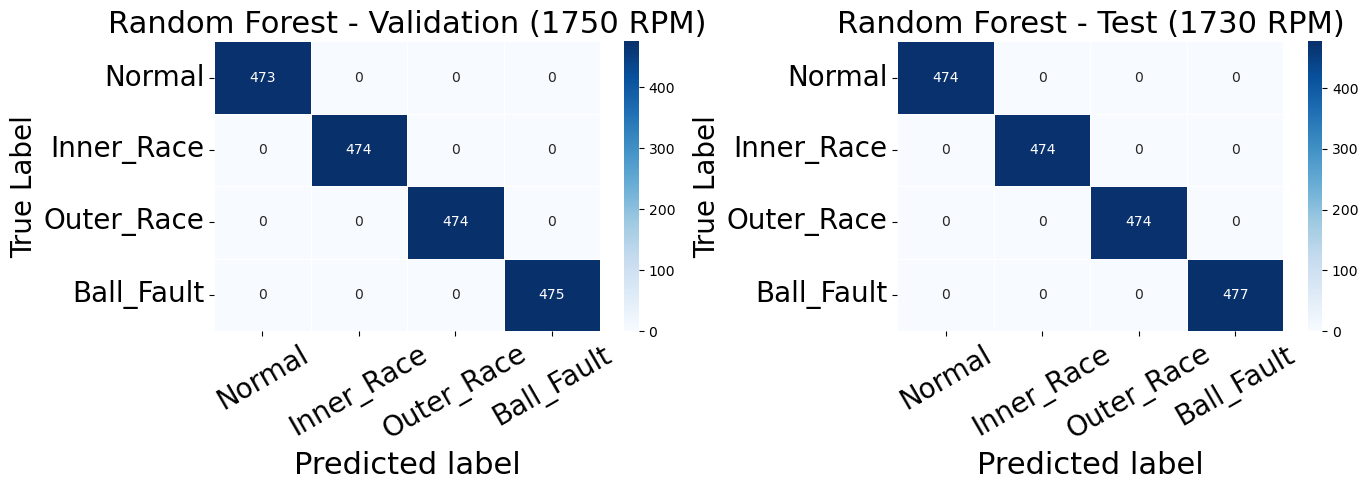

In [11]:
#Confusion matrix
classes = ["Normal", "Inner_Race", "Outer_Race", "Ball_Fault"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, predicts, title, split in zip(
    axes,
    [val_predict_rf, test_predict_rf],
    ["Random Forest - Validation (1750 RPM)",
    "Random Forest - Test (1730 RPM)"],
    [y_val, y_test]):

    cm = confusion_matrix(split, predicts, labels=classes)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=classes, yticklabels=classes,
        ax=ax, linewidths=0.5
    )
    ax.set_title(title, fontsize=22)
    ax.set_xlabel("Predicted label", fontsize=22)
    ax.set_ylabel("True Label", fontsize=20)
    ax.tick_params(axis="x", rotation=30, labelsize=20)
    ax.tick_params(axis="y", rotation=0, labelsize=20)

plt.tight_layout()
plt.show()

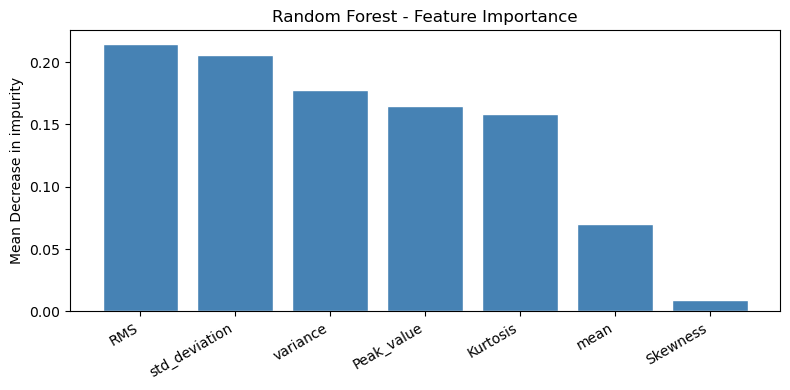

In [12]:
#Feature importance

importances = rf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 4))
plt.bar(range(len(column_names)), 
       importances[sorted_idx],
       color="steelblue", edgecolor="white")
plt.xticks(range(len(column_names)),
           [column_names[i] for i in sorted_idx],
           rotation=30, ha="right")
plt.title("Random Forest - Feature Importance")
plt.ylabel("Mean Decrease in impurity")
plt.tight_layout()
plt.show()



In [13]:
test2_predict_rf = rf.predict(x_test2_scaler)

print("Main Model - Random Forest - Unseen severity (_21) RPM 1730")
print("="*80)
print(f" Accuracy: {accuracy_score(y_test2, test2_predict_rf)}")
print(f" Macro-F1: {f1_score(y_test2, test2_predict_rf, average='macro')}")
print()
print(classification_report(y_test2, test2_predict_rf))

Main Model - Random Forest - Unseen severity (_21) RPM 1730
 Accuracy: 0.5618746708794102
 Macro-F1: 0.5600603180569352

              precision    recall  f1-score   support

  Ball_Fault       1.00      0.75      0.86       475
  Inner_Race       0.02      0.01      0.02       477
      Normal       1.00      1.00      1.00       474
  Outer_Race       0.30      0.49      0.37       473

    accuracy                           0.56      1899
   macro avg       0.58      0.56      0.56      1899
weighted avg       0.58      0.56      0.56      1899



In [14]:
import sys
print(sys.version)

3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
